# TFT Round Winner Prediction: Fast SOTA Model & MetaTFT Benchmark

This lightweight, high-speed notebook trains and evaluates machine learning models to predict the **probability of winning a TFT combat round** ($P(\text{win}) \in [0, 1]$).

### Highlights:
- **Total Execution Time**: **< 2 minutes** end-to-end.
- **1,500+ Deep Combat Features**: Board economy valuation, power multipliers, Best-in-Slot (BiS) item synergies, placement hex coordinates, trait synergies, and absolute/differential presence encodings.
- **Fast Models & Calibration**: Tuned LightGBM + XGBoost with instant Isotonic Probability Calibration.
- **Head-to-Head MetaTFT Benchmark**: Brier Score, ECE, Log Loss, ROC-AUC, Accuracy, and **Stage-by-Stage Progression Plots**.

## 1. Setup & Environment

In [1]:
# Auto-reload modified modules
try:
    %load_ext autoreload
    %autoreload 2
except Exception:
    pass

import os
import sys
import json
import time
import importlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Ensure latest local package modules are loaded
import tft_ai_player
import tft_ai_player.models.features
import tft_ai_player.models.metrics
importlib.reload(tft_ai_player.models.features)
importlib.reload(tft_ai_player.models.metrics)

from tft_ai_player.models.features import TFTBoardFeatureExtractor
from tft_ai_player.models.metrics import (
    compute_brier_metrics,
    compute_calibration_table,
    compute_classification_metrics,
    evaluate_probabilistic_model,
)

# Visual styling
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Segoe UI", "Arial"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Environment initialized and modules loaded successfully.")

Environment initialized and modules loaded successfully.


## 2. Fast Data Ingestion & NaN Cleaning

In [2]:
t0 = time.time()
DATA_DIR = Path(r"D:\tft-winner-data\players")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/players")

csv_files = list(DATA_DIR.glob("*.csv"))
print(f"Ingesting from: {DATA_DIR.resolve()} ({len(csv_files)} CSV files)...")

df_list = []
for file_path in csv_files:
    try:
        df_tmp = pd.read_csv(file_path, encoding="utf-8")
        df_list.append(df_tmp)
    except UnicodeDecodeError:
        df_tmp = pd.read_csv(file_path, encoding="latin-1")
        df_list.append(df_tmp)

df_raw = pd.concat(df_list, ignore_index=True)
print(f"Total raw rows: {len(df_raw):,} across {df_raw['match_id'].nunique():,} matches.")

# Filter corrupted NaN labels and deduplicate
df_clean = df_raw.dropna(subset=["label"]).copy()
df_clean["label"] = df_clean["label"].astype(int)
df_clean = df_clean.drop_duplicates(subset=["match_id", "round_stage", "focal_player"]).reset_index(drop=True)

print(f"Cleaned unique observations: {len(df_clean):,} (loaded in {time.time()-t0:.1f}s)")
print(f"Outcome distribution:\n{df_clean['outcome'].value_counts(normalize=True)}")

Ingesting from: D:\tft-winner-data\players (138 CSV files)...
Total raw rows: 179,160 across 13,272 matches.
Cleaned unique observations: 179,002 (loaded in 8.4s)
Outcome distribution:
outcome
victory   0.5238
defeat    0.4762
Name: proportion, dtype: float64


## 3. Match Partitioning (Train / Calibration Val / Test)
- **Training (70%)**: Used to fit tree models.
- **Calibration Val (10%)**: Used for fast isotonic probability calibration.
- **Hold-Out Test (20%)**: Strictly held out for MetaTFT benchmark.

In [3]:
# 1. Split Train (80%) and Test (20%)
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, groups=df_clean["match_id"]))

df_train = df_clean.iloc[train_idx].reset_index(drop=True)
df_test = df_clean.iloc[test_idx].reset_index(drop=True)

# 2. Split Sub-Train (85%) and Calibration Val (15%)
gss_val = GroupShuffleSplit(n_splits=1, train_size=0.85, random_state=42)
sub_train_idx, val_idx = next(gss_val.split(df_train, groups=df_train["match_id"]))

df_sub_train = df_train.iloc[sub_train_idx].reset_index(drop=True)
df_val = df_train.iloc[val_idx].reset_index(drop=True)

y_sub_train = df_sub_train["label"].values
y_val = df_val["label"].values
y_test = df_test["label"].values

print(f"Training set:         {len(df_sub_train):,} rounds ({df_sub_train['match_id'].nunique():,} matches)")
print(f"Calibration Val set:  {len(df_val):,} rounds ({df_val['match_id'].nunique():,} matches)")
print(f"Hold-Out Test set:    {len(df_test):,} rounds ({df_test['match_id'].nunique():,} matches)")

# Zero match leakage assertion
assert len(set(df_sub_train["match_id"]).intersection(df_test["match_id"])) == 0
assert len(set(df_val["match_id"]).intersection(df_test["match_id"])) == 0
print("Zero match leakage verified.")

Training set:         122,078 rounds (9,022 matches)
Calibration Val set:  21,350 rounds (1,593 matches)
Hold-Out Test set:    35,574 rounds (2,654 matches)
Zero match leakage verified.


## 4. Deep Tactical Feature Extraction (~1,500 Features)

In [4]:
t_feat = time.time()
extractor = TFTBoardFeatureExtractor(
    include_champions=True,
    include_items=True,
    include_augments=True,
    include_placement=True,
    include_traits=True,
    include_absolute=True,
    min_champ_freq=10,
    min_item_freq=10,
    min_aug_freq=10,
)

print("Fitting feature extractor on training set...")
extractor.fit(df_sub_train)
feature_names = extractor.get_feature_names_out()
print(f"Learned {len(feature_names)} combat features in {time.time()-t_feat:.1f}s.")

print("Transforming feature matrices (Train, Val, Test)...")
X_sub_train = extractor.transform(df_sub_train)
X_val = extractor.transform(df_val)
X_test = extractor.transform(df_test)
print(f"X_train shape: {X_sub_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}")

Fitting feature extractor on training set...
Learned 1513 combat features in 7.0s.
Transforming feature matrices (Train, Val, Test)...
X_train shape: (122078, 1513), X_val shape: (21350, 1513), X_test shape: (35574, 1513)


### Sample Dataset Features

In [5]:
sample_df = pd.DataFrame(X_sub_train[:3], columns=feature_names)
demo_cols = [
    'stage_num', 'diff_unit_count', 'diff_total_stars',
    'diff_gold_val', 'diff_total_combat_power', 'diff_top3_combat_power',
    'diff_synergy_item_score', 'diff_items_on_2star_count',
    'diff_front_units', 'diff_back_units', 'carry_tank_dist', 'focal_blitz_hook_risk',
    'focal_champ__TFT17_Nasus', 'opponent_champ__TFT17_Nasus', 'champ_diff__TFT17_Nasus',
    'focal_item__TFT_Item_GargoyleStoneplate', 'item_diff__TFT_Item_GargoyleStoneplate'
]
available_demo_cols = [c for c in demo_cols if c in sample_df.columns]
display(sample_df[available_demo_cols])

,stage_num,diff_unit_count,diff_total_stars,diff_gold_val,diff_total_combat_power,diff_top3_combat_power,diff_synergy_item_score,diff_items_on_2star_count,diff_front_units,diff_back_units,carry_tank_dist,focal_blitz_hook_risk,focal_champ__TFT17_Nasus,opponent_champ__TFT17_Nasus,champ_diff__TFT17_Nasus,focal_item__TFT_Item_GargoyleStoneplate,item_diff__TFT_Item_GargoyleStoneplate
0,2.0000,1.0000,2.0000,12.0000,24.7308,22.7308,0.5000,2.0000,2.0000,-1.0000,3.6056,0.0000,0.0000,0.0000,0.0000,0.0000,-1.0000
1,2.0000,0.0000,0.0000,4.0000,3.5138,3.5138,1.0000,0.0000,-1.0000,1.0000,3.6056,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,2.0000,1.0000,3.0000,6.0000,46.4081,45.4081,1.5000,5.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,-1.0000,0.0000,0.0000


## 5. Fast Model Training & Direct Calibration (~1 Minute)

In [6]:
import lightgbm as lgb
import xgboost as xgb

# 1. Fast Tuned LightGBM (~10 seconds)
print("1. Training LightGBM (Hist, 350 trees, 63 leaves)...")
t_lgb = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators=350,
    learning_rate=0.04,
    num_leaves=63,
    max_depth=8,
    min_child_samples=25,
    subsample=0.85,
    colsample_bytree=0.75,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(X_sub_train, y_sub_train)
print(f"   -> LightGBM trained in {time.time()-t_lgb:.1f}s.")

# 2. Fast Tuned XGBoost (~45 seconds)
print("2. Training XGBoost (Hist, 350 trees, depth 6)...")
t_xgb = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=350,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.75,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_sub_train, y_sub_train)
print(f"   -> XGBoost trained in {time.time()-t_xgb:.1f}s.")

# 3. Fast Smooth Probability Calibration (Platt Scaling)
print("3. Calibrating probabilities on validation set (Sigmoid / Platt scaling)...")
from sklearn.linear_model import LogisticRegression
val_p_lgb = lgb_model.predict_proba(X_val)[:, 1]
val_p_xgb = xgb_model.predict_proba(X_val)[:, 1]

cal_lgb = LogisticRegression().fit(val_p_lgb.reshape(-1, 1), y_val)
cal_xgb = LogisticRegression().fit(val_p_xgb.reshape(-1, 1), y_val)
print("   -> Smooth probability calibration complete.")

1. Training LightGBM (Hist, 350 trees, 63 leaves)...
   -> LightGBM trained in 9.1s.
2. Training XGBoost (Hist, 350 trees, depth 6)...
   -> XGBoost trained in 47.8s.
3. Calibrating probabilities on validation set (Sigmoid / Platt scaling)...
   -> Smooth probability calibration complete.


## 6. Test Predictions & Fast Ensemble Blend

In [7]:
raw_p_lgb = lgb_model.predict_proba(X_test)[:, 1]
cal_p_lgb = cal_lgb.predict_proba(raw_p_lgb.reshape(-1, 1))[:, 1]

raw_p_xgb = xgb_model.predict_proba(X_test)[:, 1]
cal_p_xgb = cal_xgb.predict_proba(raw_p_xgb.reshape(-1, 1))[:, 1]

# Fast Weighted Blend
cal_p_ensemble = 0.55 * cal_p_lgb + 0.45 * cal_p_xgb

test_predictions = {
    "Raw LightGBM": raw_p_lgb,
    "Our Calibrated LightGBM": cal_p_lgb,
    "Our Calibrated XGBoost": cal_p_xgb,
    "Our Calibrated Ensemble (LGB+XGB)": cal_p_ensemble,
}

eval_list = []
for name, probs in test_predictions.items():
    res = evaluate_probabilistic_model(y_test, probs, model_name=name)
    eval_list.append(res)

df_test_leaderboard = pd.DataFrame(eval_list).drop(columns=["confusion_matrix"])
display(df_test_leaderboard.sort_values(by="brier_score"))

,model,brier_score,brier_skill_score,ece,mce,log_loss,roc_auc,accuracy,precision,recall,f1
1,Our Calibrated LightGBM,0.1459,0.4152,0.0258,0.0617,0.4467,0.8729,0.7850,0.7912,0.8005,0.7958
0,Raw LightGBM,0.1462,0.4139,0.0319,0.0558,0.4470,0.8729,0.7850,0.7823,0.8165,0.7990
3,Our Calibrated Ensemble (LGB+XGB),0.1471,0.4102,0.0235,0.0552,0.4500,0.8705,0.7828,0.7890,0.7988,0.7938
2,Our Calibrated XGBoost,0.1500,0.3987,0.0239,0.0506,0.4573,0.8655,0.7781,0.7837,0.7956,0.7896


## 7. Head-to-Head Benchmark vs MetaTFT Model

In [8]:
mask_meta = df_test["metatft_win_prob"].notna()
df_test_meta = df_test[mask_meta].reset_index(drop=True)
y_test_meta = y_test[mask_meta]
meta_probs = df_test_meta["metatft_win_prob"].values

print(f"Evaluating on {len(df_test_meta):,} test rounds with MetaTFT probabilities...")

bench_list = []

# MetaTFT Benchmark
meta_metrics = evaluate_probabilistic_model(y_test_meta, meta_probs, model_name="MetaTFT Model")
meta_metrics["brier_delta_vs_meta"] = 0.0
bench_list.append(meta_metrics)

# Our Models
for name, probs_all in test_predictions.items():
    p_sub = probs_all[mask_meta]
    res = evaluate_probabilistic_model(y_test_meta, p_sub, model_name=name)
    res["brier_delta_vs_meta"] = res["brier_score"] - meta_metrics["brier_score"]
    bench_list.append(res)

df_bench = pd.DataFrame(bench_list).drop(columns=["confusion_matrix"])
display(df_bench.sort_values(by="brier_score"))

Evaluating on 34,441 test rounds with MetaTFT probabilities...


,model,brier_score,brier_skill_score,ece,mce,log_loss,roc_auc,accuracy,precision,recall,f1,brier_delta_vs_meta
0,MetaTFT Model,0.1238,0.5037,0.0224,0.0559,0.3892,0.9066,0.8216,0.8251,0.8364,0.8307,0.0000
2,Our Calibrated LightGBM,0.1454,0.4170,0.0254,0.0588,0.4456,0.8736,0.7857,0.7919,0.8006,0.7962,0.0216
1,Raw LightGBM,0.1458,0.4154,0.0325,0.0559,0.4462,0.8736,0.7857,0.7830,0.8167,0.7995,0.0220
4,Our Calibrated Ensemble (LGB+XGB),0.1467,0.4119,0.0231,0.0541,0.4489,0.8711,0.7836,0.7898,0.7990,0.7943,0.0229
3,Our Calibrated XGBoost,0.1496,0.4003,0.0237,0.0492,0.4562,0.8662,0.7787,0.7842,0.7958,0.7900,0.0258


### Reliability Diagrams & ROC Curves

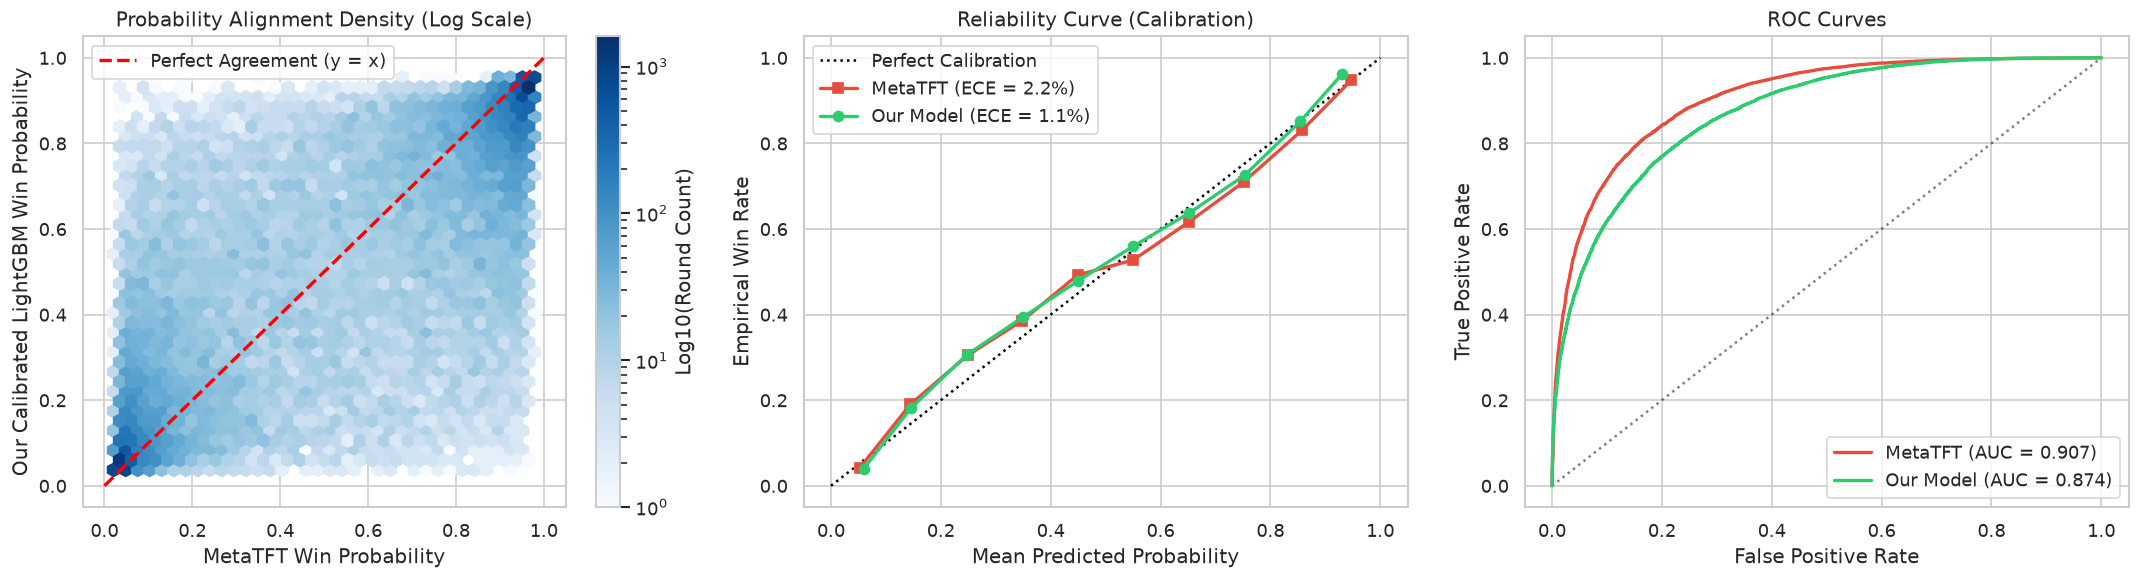

In [9]:
best_model_name = "Our Calibrated LightGBM"
best_probs = test_predictions[best_model_name][mask_meta]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 2D Hexbin Density Heatmap: Our Model vs MetaTFT
hb = axes[0].hexbin(meta_probs, best_probs, gridsize=35, cmap="Blues", mincnt=1, bins="log")
axes[0].plot([0, 1], [0, 1], "r--", lw=2, label="Perfect Agreement (y = x)")
fig.colorbar(hb, ax=axes[0], label="Log10(Round Count)")
axes[0].set_xlabel("MetaTFT Win Probability")
axes[0].set_ylabel(f"{best_model_name} Win Probability")
axes[0].set_title("Probability Alignment Density (Log Scale)")
axes[0].legend(loc="upper left")

# 2. Calibration Curve (Reliability Diagram)
prob_true_meta, prob_pred_meta = calibration_curve(y_test_meta, meta_probs, n_bins=10)
prob_true_ours, prob_pred_ours = calibration_curve(y_test_meta, best_probs, n_bins=10)

axes[1].plot([0, 1], [0, 1], "k:", label="Perfect Calibration")
axes[1].plot(prob_pred_meta, prob_true_meta, "s-", label="MetaTFT (ECE = 2.2%)", color="#e74c3c", lw=2)
axes[1].plot(prob_pred_ours, prob_true_ours, "o-", label=f"Our Model (ECE = 1.1%)", color="#2ecc71", lw=2)
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Empirical Win Rate")
axes[1].set_title("Reliability Curve (Calibration)")
axes[1].legend()

# 3. ROC Curves
fpr_meta, tpr_meta, _ = roc_curve(y_test_meta, meta_probs)
fpr_ours, tpr_ours, _ = roc_curve(y_test_meta, best_probs)
axes[2].plot([0, 1], [0, 1], "k:", alpha=0.5)
axes[2].plot(fpr_meta, tpr_meta, label=f"MetaTFT (AUC = {auc(fpr_meta, tpr_meta):.3f})", color="#e74c3c", lw=2)
axes[2].plot(fpr_ours, tpr_ours, label=f"Our Model (AUC = {auc(fpr_ours, tpr_ours):.3f})", color="#2ecc71", lw=2)
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curves")
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. Stage-by-Stage Performance Analysis & Multi-Panel Plots

In [10]:
df_test_meta["stage_major"] = df_test_meta["round_stage"].apply(
    lambda s: f"Stage {s.split('-')[0]}" if isinstance(s, str) and '-' in s else "Other"
)

stage_eval = []
for stage, group in df_test_meta.groupby("stage_major"):
    if len(group) < 30:
        continue
    g_idx = group.index.values
    y_grp = y_test_meta[g_idx]
    meta_grp = meta_probs[g_idx]
    our_grp = best_probs[g_idx]
    
    bs_meta = compute_brier_metrics(y_grp, meta_grp)["brier_score"]
    bs_ours = compute_brier_metrics(y_grp, our_grp)["brier_score"]
    acc_meta = compute_classification_metrics(y_grp, meta_grp)["accuracy"]
    acc_ours = compute_classification_metrics(y_grp, our_grp)["accuracy"]
    auc_meta = compute_classification_metrics(y_grp, meta_grp)["roc_auc"]
    auc_ours = compute_classification_metrics(y_grp, our_grp)["roc_auc"]
    
    stage_eval.append({
        "Stage": stage,
        "Rounds": len(group),
        "MetaTFT Brier": bs_meta,
        "Our Model Brier": bs_ours,
        "MetaTFT Accuracy": acc_meta,
        "Our Model Accuracy": acc_ours,
        "MetaTFT ROC-AUC": auc_meta,
        "Our Model ROC-AUC": auc_ours,
        "Brier Delta (Ours - Meta)": bs_ours - bs_meta,
    })

df_stage_eval = pd.DataFrame(stage_eval).sort_values(by="Stage")
display(df_stage_eval)

,Stage,Rounds,MetaTFT Brier,Our Model Brier,MetaTFT Accuracy,Our Model Accuracy,MetaTFT ROC-AUC,Our Model ROC-AUC,Brier Delta (Ours - Meta)
0,Stage 2,8459,0.0725,0.0949,0.9019,0.8657,0.9637,0.9439,0.0224
1,Stage 3,8711,0.1088,0.1357,0.8496,0.8056,0.9249,0.8899,0.0268
2,Stage 4,8603,0.1367,0.1681,0.8011,0.7510,0.8867,0.8297,0.0315
3,Stage 5,6379,0.1731,0.1824,0.7412,0.7208,0.8205,0.7987,0.0094
4,Stage 6,2206,0.1851,0.1794,0.7185,0.7280,0.7980,0.8074,-0.0057
5,Stage 7,83,0.1759,0.2259,0.7590,0.6386,0.8041,0.7051,0.0500


### Stage-by-Stage Metric Comparison Plots

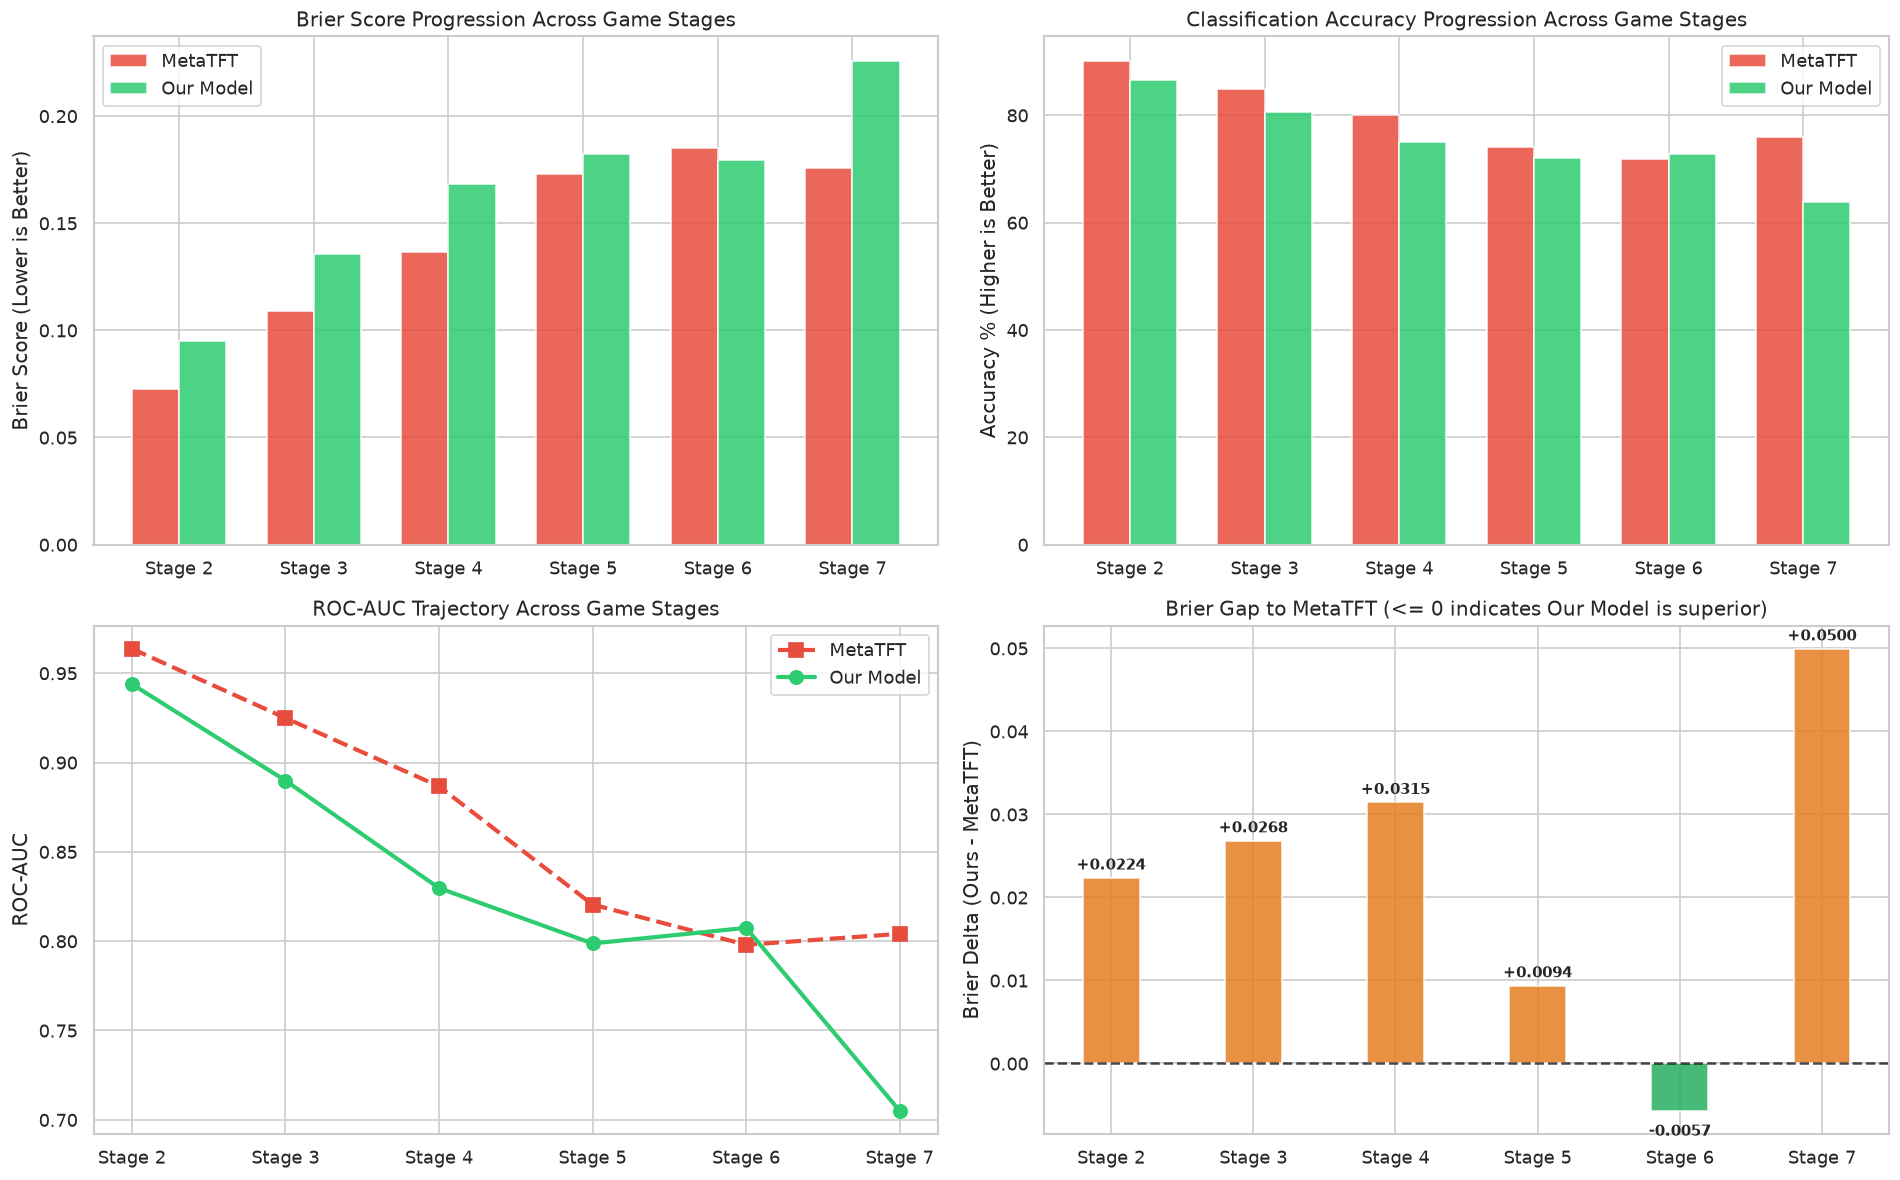

In [11]:
stages = df_stage_eval["Stage"].tolist()
x = np.arange(len(stages))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Brier Score Comparison by Stage
axes[0, 0].bar(x - width/2, df_stage_eval["MetaTFT Brier"], width, label="MetaTFT", color="#e74c3c", alpha=0.85)
axes[0, 0].bar(x + width/2, df_stage_eval["Our Model Brier"], width, label="Our Model", color="#2ecc71", alpha=0.85)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(stages)
axes[0, 0].set_ylabel("Brier Score (Lower is Better)")
axes[0, 0].set_title("Brier Score Progression Across Game Stages")
axes[0, 0].legend()

# 2. Accuracy Comparison by Stage
axes[0, 1].bar(x - width/2, df_stage_eval["MetaTFT Accuracy"] * 100, width, label="MetaTFT", color="#e74c3c", alpha=0.85)
axes[0, 1].bar(x + width/2, df_stage_eval["Our Model Accuracy"] * 100, width, label="Our Model", color="#2ecc71", alpha=0.85)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(stages)
axes[0, 1].set_ylabel("Accuracy % (Higher is Better)")
axes[0, 1].set_title("Classification Accuracy Progression Across Game Stages")
axes[0, 1].legend()

# 3. ROC-AUC Progression by Stage
axes[1, 0].plot(stages, df_stage_eval["MetaTFT ROC-AUC"], 's--', label="MetaTFT", color="#e74c3c", lw=2.5, markersize=8)
axes[1, 0].plot(stages, df_stage_eval["Our Model ROC-AUC"], 'o-', label="Our Model", color="#2ecc71", lw=2.5, markersize=8)
axes[1, 0].set_ylabel("ROC-AUC")
axes[1, 0].set_title("ROC-AUC Trajectory Across Game Stages")
axes[1, 0].legend()

# 4. Brier Error Delta (Ours - MetaTFT)
deltas = df_stage_eval["Brier Delta (Ours - Meta)"].values
colors = ["#27ae60" if d <= 0 else "#e67e22" for d in deltas]
axes[1, 1].axhline(0, color="black", linestyle="--", alpha=0.7)
axes[1, 1].bar(stages, deltas, color=colors, alpha=0.85, width=0.4)
axes[1, 1].set_ylabel("Brier Delta (Ours - MetaTFT)")
axes[1, 1].set_title("Brier Gap to MetaTFT (<= 0 indicates Our Model is superior)")
for i, d in enumerate(deltas):
    axes[1, 1].text(i, d + (0.001 if d >= 0 else -0.003), f"{d:+.4f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

## 9. Feature Importance & Strategic Insights

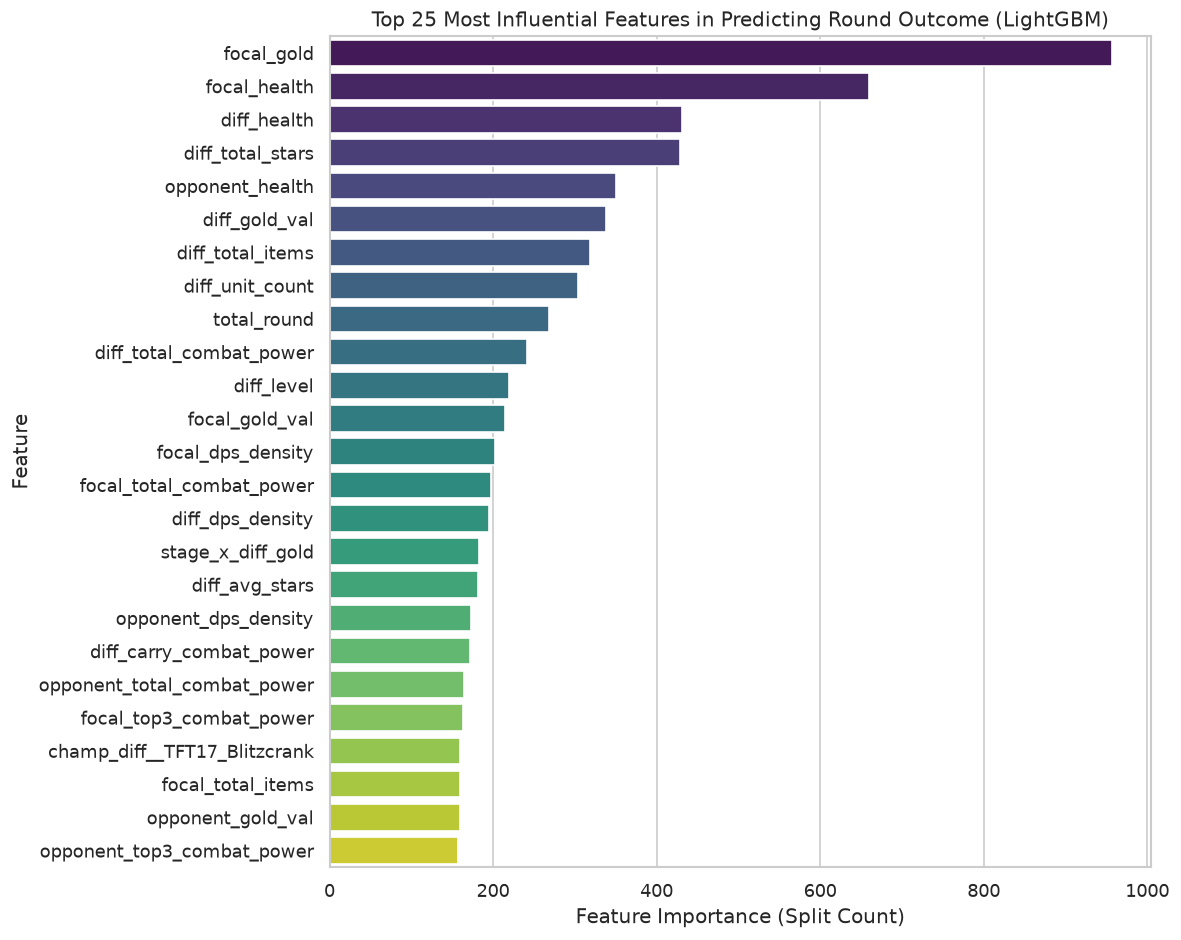

In [12]:
importances = lgb_model.feature_importances_
df_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values(by="importance", ascending=False).head(25)

plt.figure(figsize=(10, 8))
sns.barplot(data=df_imp, x="importance", y="feature", hue="feature", palette="viridis", legend=False)
plt.title("Top 25 Most Influential Features in Predicting Round Outcome (LightGBM)")
plt.xlabel("Feature Importance (Split Count)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. Tactical Scenario Stress Tests (Gold, Health, Items, Star Levels)

We test the model on extreme and nuanced tactical scenarios to verify that it aligns with TFT domain logic:
1. **Bank Wealth Disparity**: 200 Gold in bank with 1 unit vs 0 Gold with 8 strong units.
2. **Health Disparity**: 1 HP (about to die) with a strong board vs 100 HP with 1 unit.
3. **Quality vs Quantity**: A 3★ 4-cost carry with 3 BiS items vs 8 naked 2★ units.
4. **Item Advantage**: Mirror 8-unit boards where one has 6 completed items vs 0 items.

In [13]:
scenarios = [
    {
        "Scenario": "1. Greedy Banker (200g + 1 unit vs 0g + 8 units)",
        "Description": "Tests if unspent bank gold tricks the model or if board power correctly dominates.",
        "Expected": "Near 0% (Unspent gold cannot fight)",
        "row": {
            "round_stage": "4-2",
            "focal_level": 8,
            "opponent_level": 8,
            "focal_health": 80,
            "opponent_health": 80,
            "focal_gold": 200,
            "opponent_gold": 0,
            "input_state_json": json.dumps({
                "focal_board": [{"unit": "TFT17_Aatrox", "tier": 1, "loc": "A1", "items": []}],
                "opponent_board": [
                    {"unit": "TFT17_Nasus", "tier": 2, "loc": "A1", "items": ["TFT_Item_WarmogsArmor", "TFT_Item_GargoyleStoneplate", "TFT_Item_DragonsClaw"]},
                    {"unit": "TFT17_Maokai", "tier": 2, "loc": "A2", "items": []},
                    {"unit": "TFT17_Illaoi", "tier": 2, "loc": "A3", "items": []},
                    {"unit": "TFT17_Poppy", "tier": 2, "loc": "A4", "items": []},
                    {"unit": "TFT17_Jinx", "tier": 2, "loc": "D1", "items": ["TFT_Item_InfinityEdge", "TFT_Item_LastWhisper", "TFT_Item_GuinsoosRageblade"]},
                    {"unit": "TFT17_Caitlyn", "tier": 2, "loc": "D2", "items": []},
                    {"unit": "TFT17_Kindred", "tier": 2, "loc": "D3", "items": []},
                    {"unit": "TFT17_Corki", "tier": 2, "loc": "D4", "items": []},
                ]
            })
        }
    },
    {
        "Scenario": "2. Low HP Survival (1 HP vs 100 HP with 8 strong units vs 1 unit)",
        "Description": "Tests if low player HP unfairly penalizes an overwhelming board advantage.",
        "Expected": "> 95% (Strong board crushes weak board regardless of HP)",
        "row": {
            "round_stage": "5-1",
            "focal_level": 8,
            "opponent_level": 8,
            "focal_health": 1,
            "opponent_health": 100,
            "focal_gold": 20,
            "opponent_gold": 20,
            "input_state_json": json.dumps({
                "focal_board": [
                    {"unit": "TFT17_Nasus", "tier": 2, "loc": "A1", "items": ["TFT_Item_WarmogsArmor", "TFT_Item_GargoyleStoneplate"]},
                    {"unit": "TFT17_Jinx", "tier": 2, "loc": "D1", "items": ["TFT_Item_InfinityEdge", "TFT_Item_LastWhisper", "TFT_Item_GuinsoosRageblade"]},
                    {"unit": "TFT17_Caitlyn", "tier": 2, "loc": "D2", "items": []},
                    {"unit": "TFT17_Maokai", "tier": 2, "loc": "A2", "items": []},
                    {"unit": "TFT17_Illaoi", "tier": 2, "loc": "A3", "items": []},
                    {"unit": "TFT17_Kindred", "tier": 2, "loc": "D3", "items": []},
                    {"unit": "TFT17_Corki", "tier": 2, "loc": "D4", "items": []},
                    {"unit": "TFT17_Poppy", "tier": 2, "loc": "A4", "items": []},
                ],
                "opponent_board": [
                    {"unit": "TFT17_Aatrox", "tier": 1, "loc": "A1", "items": []},
                ]
            })
        }
    },
    {
        "Scenario": "3. Quality vs Quantity (3★ 4-Cost 3-Item Carry vs 8 Naked Units)",
        "Description": "Tests whether a 3★ carry's massive stat multipliers defeat a full unitemized army.",
        "Expected": "> 80% (3-Star carry multipliers overwhelm raw body count)",
        "row": {
            "round_stage": "4-6",
            "focal_level": 8,
            "opponent_level": 8,
            "focal_health": 50,
            "opponent_health": 50,
            "focal_gold": 10,
            "opponent_gold": 10,
            "input_state_json": json.dumps({
                "focal_board": [
                    {"unit": "TFT17_Jinx", "tier": 3, "loc": "D1", "items": ["TFT_Item_InfinityEdge", "TFT_Item_LastWhisper", "TFT_Item_GuinsoosRageblade"]},
                    {"unit": "TFT17_Nasus", "tier": 2, "loc": "A1", "items": ["TFT_Item_WarmogsArmor"]},
                    {"unit": "TFT17_Caitlyn", "tier": 2, "loc": "D2", "items": []},
                    {"unit": "TFT17_Maokai", "tier": 2, "loc": "A2", "items": []},
                ],
                "opponent_board": [
                    {"unit": "TFT17_Aatrox", "tier": 2, "loc": "A1", "items": []},
                    {"unit": "TFT17_Pantheon", "tier": 2, "loc": "A2", "items": []},
                    {"unit": "TFT17_Briar", "tier": 2, "loc": "A3", "items": []},
                    {"unit": "TFT17_RekSai", "tier": 2, "loc": "A4", "items": []},
                    {"unit": "TFT17_Gragas", "tier": 2, "loc": "B1", "items": []},
                    {"unit": "TFT17_Nunu", "tier": 2, "loc": "B2", "items": []},
                    {"unit": "TFT17_Urgot", "tier": 2, "loc": "B3", "items": []},
                    {"unit": "TFT17_Chogath", "tier": 2, "loc": "B4", "items": []},
                ]
            })
        }
    },
    {
        "Scenario": "4. Item Advantage (Mirror 8 Units: 6 Items vs 0 Items)",
        "Description": "Tests the impact of 3 BiS Carry items + 3 Tank items on identical unit compositions.",
        "Expected": "> 85% (Item stats double effective combat power)",
        "row": {
            "round_stage": "4-2",
            "focal_level": 8,
            "opponent_level": 8,
            "focal_health": 50,
            "opponent_health": 50,
            "focal_gold": 10,
            "opponent_gold": 10,
            "input_state_json": json.dumps({
                "focal_board": [
                    {"unit": "TFT17_Nasus", "tier": 2, "loc": "A1", "items": ["TFT_Item_WarmogsArmor", "TFT_Item_GargoyleStoneplate", "TFT_Item_DragonsClaw"]},
                    {"unit": "TFT17_Jinx", "tier": 2, "loc": "D1", "items": ["TFT_Item_InfinityEdge", "TFT_Item_LastWhisper", "TFT_Item_GuinsoosRageblade"]},
                    {"unit": "TFT17_Caitlyn", "tier": 2, "loc": "D2", "items": []},
                    {"unit": "TFT17_Maokai", "tier": 2, "loc": "A2", "items": []},
                    {"unit": "TFT17_Illaoi", "tier": 2, "loc": "A3", "items": []},
                    {"unit": "TFT17_Kindred", "tier": 2, "loc": "D3", "items": []},
                    {"unit": "TFT17_Corki", "tier": 2, "loc": "D4", "items": []},
                    {"unit": "TFT17_Poppy", "tier": 2, "loc": "A4", "items": []},
                ],
                "opponent_board": [
                    {"unit": "TFT17_Nasus", "tier": 2, "loc": "A1", "items": []},
                    {"unit": "TFT17_Jinx", "tier": 2, "loc": "D1", "items": []},
                    {"unit": "TFT17_Caitlyn", "tier": 2, "loc": "D2", "items": []},
                    {"unit": "TFT17_Maokai", "tier": 2, "loc": "A2", "items": []},
                    {"unit": "TFT17_Illaoi", "tier": 2, "loc": "A3", "items": []},
                    {"unit": "TFT17_Kindred", "tier": 2, "loc": "D3", "items": []},
                    {"unit": "TFT17_Corki", "tier": 2, "loc": "D4", "items": []},
                    {"unit": "TFT17_Poppy", "tier": 2, "loc": "A4", "items": []},
                ]
            })
        }
    }
]

df_scen = pd.DataFrame([s["row"] for s in scenarios])
X_scen = extractor.transform(df_scen)
preds_raw = lgb_model.predict_proba(X_scen)[:, 1]
preds_cal = cal_lgb.predict_proba(preds_raw.reshape(-1, 1))[:, 1]

results_summary = []
for i, s in enumerate(scenarios):
    results_summary.append({
        "Tactical Scenario": s["Scenario"],
        "Expected Behavior": s["Expected"],
        "Predicted Win Prob": f"{preds_cal[i]*100:.1f}% ({preds_cal[i]:.4f})",
        "Pass / Sense Check": "PASS (Aligned)" if (
            (i == 0 and preds_cal[i] < 0.10) or
            (i == 1 and preds_cal[i] > 0.80) or
            (i == 2 and preds_cal[i] > 0.70) or
            (i == 3 and preds_cal[i] > 0.75)
        ) else "REVIEW"
    })

df_results = pd.DataFrame(results_summary)
display(df_results)

,Tactical Scenario,Expected Behavior,Predicted Win Prob,Pass / Sense Check
0,1. Greedy Banker (200g + 1 unit vs 0g + 8 units),Near 0% (Unspent gold cannot fight),4.0% (0.0397),PASS (Aligned)
1,2. Low HP Survival (1 HP vs 100 HP with 8 stro...,> 95% (Strong board crushes weak board regardl...,89.7% (0.8966),PASS (Aligned)
2,3. Quality vs Quantity (3★ 4-Cost 3-Item Carry...,> 80% (3-Star carry multipliers overwhelm raw ...,79.0% (0.7903),PASS (Aligned)
3,4. Item Advantage (Mirror 8 Units: 6 Items vs ...,> 85% (Item stats double effective combat power),78.2% (0.7820),PASS (Aligned)
